-- this file is uses to train the feritilizer prediction model ----

In [109]:
import pandas as pd,matplotlib.pyplot as plt, seaborn as sns, numpy as np 

In [110]:
df = pd.read_csv(r"C:\Users\kokch\45_days_Training\Machine_Learning\Farmerguiderapp\datasets\fertilizer_recommendation_dataset.csv", encoding="latin-1")

-- understanding the dataset ----

In [111]:
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [112]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   str    
 9   Crop         3100 non-null   str    
 10  Fertilizer   3100 non-null   str    
 11  Remark       3100 non-null   str    
dtypes: float64(8), str(4)
memory usage: 290.8 KB


In [113]:
df.describe()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000
mean,27.271096,0.600763,111.024949,6.379775,61.278480,69.582850,69.721167,1.474325
std,9.114450,0.144947,77.151880,0.957103,10.186410,42.226712,35.304241,0.698300
min,4.011486,0.227436,-85.709593,3.448974,35.527718,-37.649739,-20.509108,-0.280560
25%,22.408505,0.493595,61.283985,5.860489,54.835715,43.039260,49.992405,0.956401
50%,26.132938,0.599520,96.485935,6.337308,59.429649,58.205269,58.710808,1.463357
75%,29.987887,0.708575,147.619401,6.899739,65.792790,86.108983,76.318626,2.003534
max,56.653592,0.972361,411.955947,9.562341,98.581039,177.314481,161.067982,3.241984


In [114]:
df.columns.unique

<bound method Index.unique of Index(['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous',
       'Potassium', 'Carbon', 'Soil', 'Crop', 'Fertilizer', 'Remark'],
      dtype='str')>

In [115]:
df.isnull().sum()

Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64

In [116]:
df.duplicated().sum()

np.int64(0)

--- EDA -----

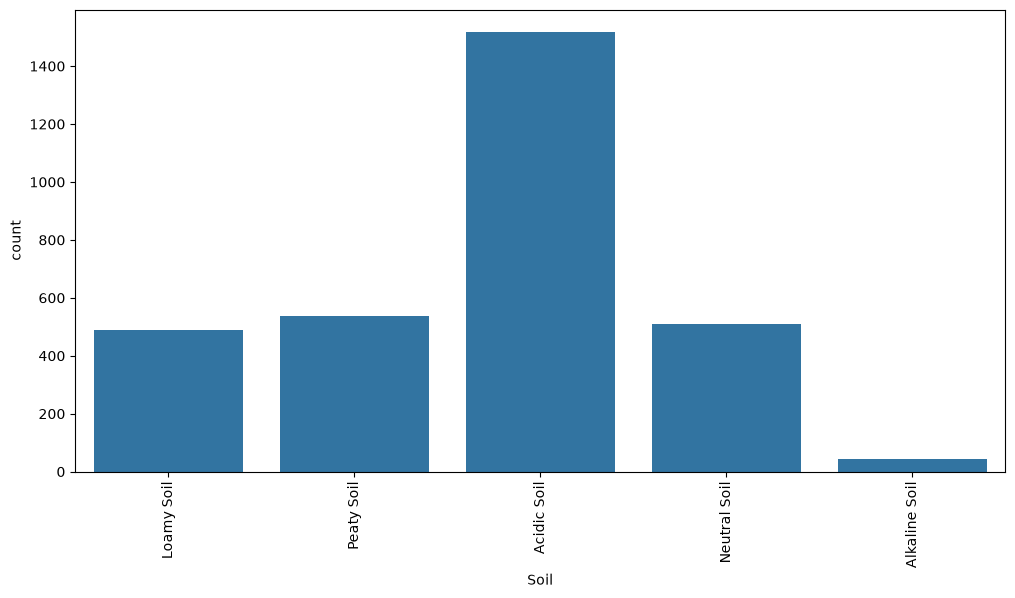

In [117]:
plt.figure(figsize=(12,6))
sns.countplot(x='Soil',data=df)
plt.xticks(rotation=90)
plt.show()

In [118]:
df.dtypes

Temperature    float64
Moisture       float64
Rainfall       float64
PH             float64
Nitrogen       float64
Phosphorous    float64
Potassium      float64
Carbon         float64
Soil               str
Crop               str
Fertilizer         str
Remark             str
dtype: object

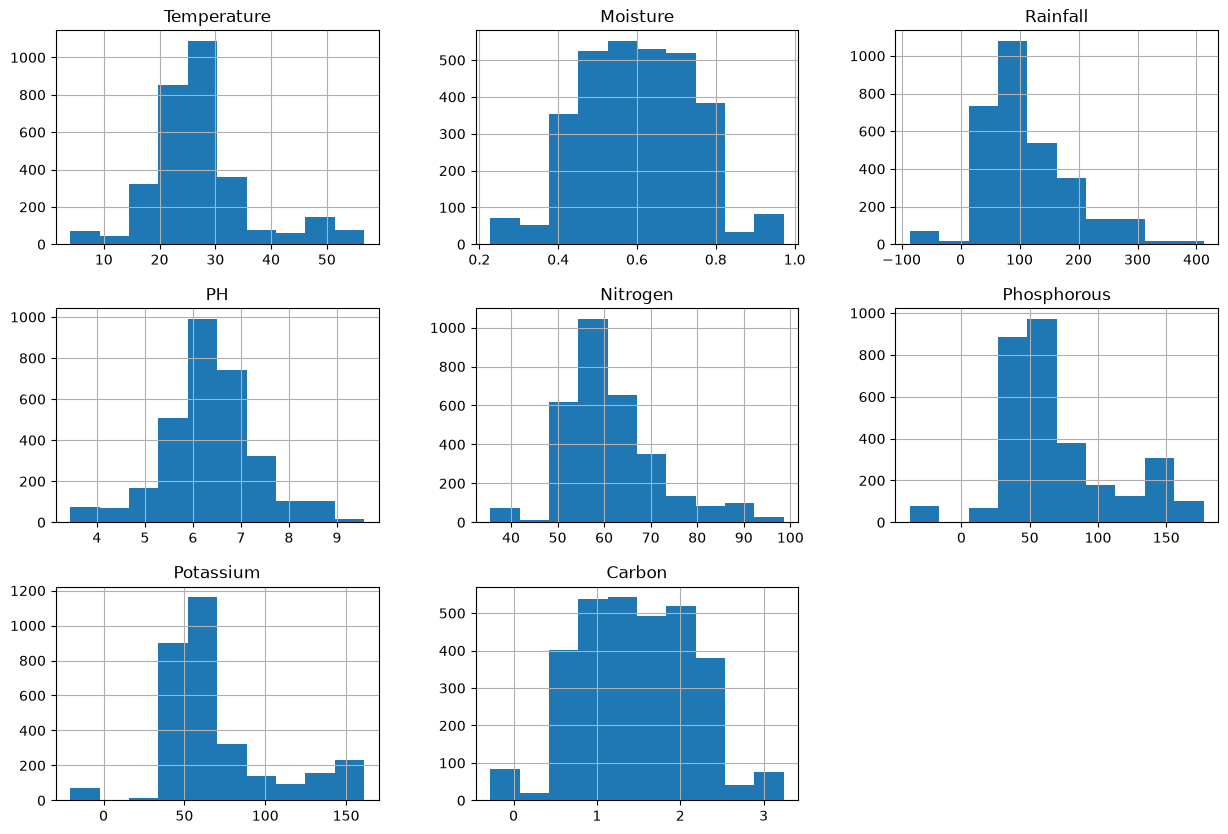

In [119]:
df.hist(figsize=(15,10))
plt.show()

In [120]:
from sklearn.preprocessing import LabelEncoder

In [121]:
encoder = LabelEncoder()
df["Fertilizer"]= encoder.fit_transform(df["Fertilizer"])
soil_encoder = LabelEncoder()
df["Soil"] = soil_encoder.fit_transform(df["Soil"])

crop_encoder = LabelEncoder()
df["Crop"] = crop_encoder.fit_transform(df["Crop"])

remark_encoder = LabelEncoder()
df["Remark"] = remark_encoder.fit_transform(df["Remark"])


In [122]:
import pickle

encoders = {
    "soil_encoder": soil_encoder,
    "crop_encoder": crop_encoder,
    "remark_encoder": remark_encoder,
    "encoder": encoder
}

with open(r"C:\Users\kokch\45_days_Training\Machine_Learning\Farmerguiderapp\model\encoders2.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [123]:
x = df.drop(["Fertilizer","Remark"], axis = 1)
y = df["Fertilizer"]

In [124]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [125]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [126]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [127]:
pickle.dump(scaler,open(r"C:\Users\kokch\45_days_Training\Machine_Learning\Farmerguiderapp\model\scaler2.pkl","wb"))

In [128]:
from sklearn.ensemble import RandomForestClassifier


In [129]:
model = RandomForestClassifier(random_state=42)
model.fit(x_train,y_train)
print(model)

RandomForestClassifier(random_state=42)


In [130]:
pickle.dump(model,open(r"C:\Users\kokch\45_days_Training\Machine_Learning\Farmerguiderapp\model\best_model2.pkl","wb"))